# Midterm Mini-Project (Modules 1–7): End-to-End Supervised ML System  
**Student:** Cristian Negrin  
**Dataset:** `midterm_energyops_dataset.csv` (Energy Operations)  
**Targets:**  
- Regression: `energy_kwh` (continuous)  
- Classification: `high_peak` (binary)  

This notebook implements an end-to-end ML system: data prep → math foundations → multiple supervised models → evaluation → recommendation.


## Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    root_mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA


## Load data + time-aware split

In [2]:

csv_path = "midterm_energyops_dataset.csv"
df = pd.read_csv(csv_path)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

target_reg = "energy_kwh"
target_clf = "high_peak"

X = df.drop(columns=[target_reg, target_clf, "timestamp"])
y_reg = df[target_reg]
y_clf = df[target_clf]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# Time-aware split: first 60% train, next 20% val, last 20% test
n = len(df)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

X_train, X_val, X_test = X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:]
yreg_train, yreg_val, yreg_test = y_reg.iloc[:train_end], y_reg.iloc[train_end:val_end], y_reg.iloc[val_end:]
yclf_train, yclf_val, yclf_test = y_clf.iloc[:train_end], y_clf.iloc[train_end:val_end], y_clf.iloc[val_end:]

df.head(), df.shape


(            timestamp region  building_type day_of_week  hour  month  \
 0 2025-01-01 01:00:00  South    Residential   Wednesday     1      1   
 1 2025-01-01 01:00:00   East  SmallBusiness   Wednesday     1      1   
 2 2025-01-01 02:00:00   West  SmallBusiness   Wednesday     2      1   
 3 2025-01-01 02:00:00  South  SmallBusiness   Wednesday     2      1   
 4 2025-01-01 03:00:00  North  SmallBusiness   Wednesday     3      1   
 
    temperature_c  humidity  wind_kph  square_feet  ...  occupancy  \
 0          17.70     14.95     21.50         1993  ...          3   
 1           6.43     61.92     23.01         7515  ...          8   
 2          35.63     51.14     15.32         3375  ...         11   
 3          39.61     61.23     16.85         5356  ...          8   
 4          25.64     58.56     16.34         3477  ...          6   
 
    hvac_runtime_min  computer_hours  cooking_events  ev_charging  solar_kw  \
 0              48.9            2.33               2       

## Part 1 — Mathematical Foundations (Modules 1–3)

### Task 1: Linear Algebra & Data Representation

We represent the dataset as a **feature matrix** \(X\) and a **target vector** \(y\).  
- \(X \in \mathbb{R}^{m 	imes n}\) (m rows = samples, n columns = features)  
- \(y \in \mathbb{R}^{m}\) (regression) or \(y \in \{0,1\}^{m}\) (classification)

Because we have categorical features, we use one-hot encoding so the final matrix is numerical.


In [3]:

# Fit preprocessing on train to define the final matrix
preprocess.fit(X_train)

Xtr = preprocess.transform(X_train)
Xte = preprocess.transform(X_test)

print("X (train) shape:", Xtr.shape)
print("y_reg (train) shape:", yreg_train.shape)
print("y_clf (train) shape:", yclf_train.shape)

# Rank discussion (after one-hot + scaling)
rank = np.linalg.matrix_rank(Xtr)
print("Matrix rank of X (train):", rank)

print("\nRank vs #features:")
print("rank =", rank, " ; n_features =", Xtr.shape[1])

# Invertibility note:
# X^T X is invertible only if X has full column rank (rank == n_features).


X (train) shape: (3000, 31)
y_reg (train) shape: (3000,)
y_clf (train) shape: (3000,)
Matrix rank of X (train): 28

Rank vs #features:
rank = 28  ; n_features = 31


**Rank / invertibility (discussion):**  
If `rank < n_features`, then the columns are linearly dependent (common with one-hot encoding + correlated signals).  
In that case, \(X^T X\) is not invertible, which is one reason we prefer:  
- regularization (Ridge/Lasso)  
- numerical solvers (SVD-based)  
- dimensionality reduction (PCA/SVD)


### PCA / SVD compression (why decomposition matters)

PC01: explained=0.1399  cumulative=0.1399
PC02: explained=0.0896  cumulative=0.2296
PC03: explained=0.0793  cumulative=0.3088
PC04: explained=0.0697  cumulative=0.3786
PC05: explained=0.0620  cumulative=0.4406
PC06: explained=0.0603  cumulative=0.5009
PC07: explained=0.0602  cumulative=0.5611
PC08: explained=0.0583  cumulative=0.6194
PC09: explained=0.0576  cumulative=0.6770
PC10: explained=0.0484  cumulative=0.7254


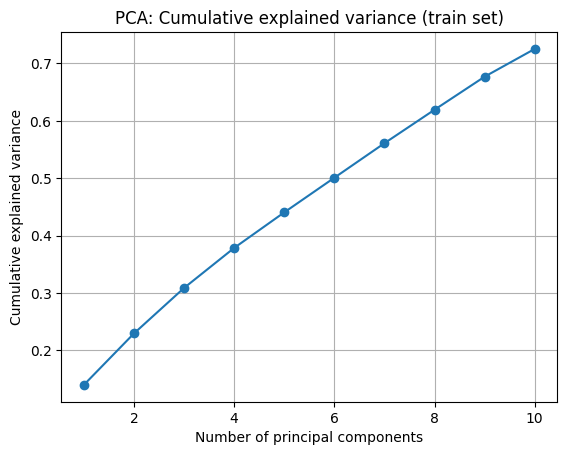

In [4]:

from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)
pca.fit(Xtr)

explained = pca.explained_variance_ratio_
cum = np.cumsum(explained)

for i,(e,c) in enumerate(zip(explained, cum), start=1):
    print(f"PC{i:02d}: explained={e:.4f}  cumulative={c:.4f}")

plt.figure()
plt.plot(np.arange(1, len(cum)+1), cum, marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA: Cumulative explained variance (train set)")
plt.grid(True)
plt.show()


**Why decomposition matters:**  
PCA/SVD finds orthogonal directions that capture most variance. This helps:
- compress data (fewer dimensions)  
- reduce multicollinearity  
- speed up training  
- sometimes improve generalization (less noise)


### Task 2: Optimization & Gradient Descent (from scratch)

We implement Gradient Descent for **linear regression** (predicting `energy_kwh`).  

**Model:** \(\hat{y} = Xw\) (with a bias term)  
**Loss (MSE):** \(J(w) = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2\)  
**Gradient:** \(\nabla J(w) = \frac{2}{m}X^T(Xw - y)\)

We compare convergence under two learning rates.


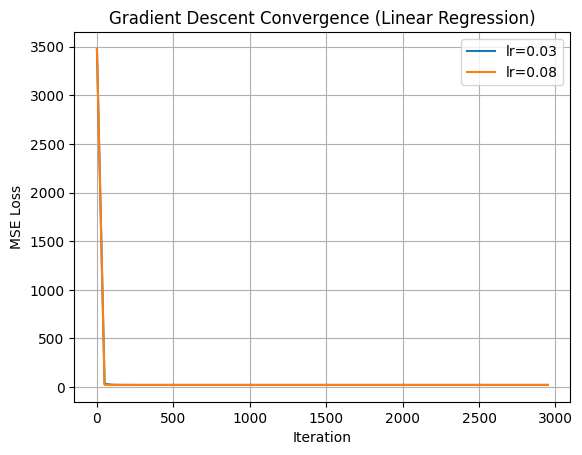

(5.010576181124635, 0.9643045211959451)

In [5]:

# Prepare numeric matrix using the same preprocess (already fit above)
Xtr = preprocess.transform(X_train)
Xte = preprocess.transform(X_test)

ytr = yreg_train.to_numpy().reshape(-1, 1)
yte = yreg_test.to_numpy().reshape(-1, 1)

# Add bias term
Xtr_b = np.c_[np.ones((Xtr.shape[0], 1)), Xtr]
Xte_b = np.c_[np.ones((Xte.shape[0], 1)), Xte]

def gd_linear_regression(X, y, lr=0.05, iters=3000):
    m, n = X.shape
    w = np.zeros((n, 1))
    losses = []
    for i in range(iters):
        yhat = X @ w
        err = yhat - y
        loss = float((err**2).mean())
        grad = (2/m) * (X.T @ err)
        w -= lr * grad
        if i % 50 == 0:
            losses.append(loss)
    return w, losses

w_a, losses_a = gd_linear_regression(Xtr_b, ytr, lr=0.03, iters=3000)
w_b, losses_b = gd_linear_regression(Xtr_b, ytr, lr=0.08, iters=3000)

plt.figure()
plt.plot(np.arange(len(losses_a))*50, losses_a, label="lr=0.03")
plt.plot(np.arange(len(losses_b))*50, losses_b, label="lr=0.08")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence (Linear Regression)")
plt.grid(True)
plt.legend()
plt.show()

# Evaluate the better run on test
w_best = w_a if losses_a[-1] <= losses_b[-1] else w_b
pred_test = Xte_b @ w_best

rmse = root_mean_squared_error(yte, pred_test)
r2 = r2_score(yte, pred_test)

rmse, r2


**Learning rate impact (discussion):**  
- Too small → converges slowly.  
- Too large → may oscillate or diverge.  
Scikit-Learn’s `LinearRegression` typically uses stable numerical solvers (often SVD-based), so it does not require manual learning-rate tuning.


### Task 3: Probability & Bayesian Reasoning (Naive Bayes / MLE)

We implement **Gaussian Naive Bayes** for `high_peak`.

**Assumptions:**
- Features are conditionally independent given the class (naive independence).  
- Each feature is modeled as a Gaussian distribution within each class.  
- Parameters (mean/variance per feature per class) are estimated via **Maximum Likelihood Estimation (MLE)** from the training data.

Even though the independence assumption is rarely perfectly true, Naive Bayes can still work well in practice and provides interpretable probabilistic outputs.


In [6]:

# Gaussian Naive Bayes (needs dense arrays; ours are dense)
Xtr = preprocess.transform(X_train)
Xte = preprocess.transform(X_test)

nb = GaussianNB()
nb.fit(Xtr, yclf_train)

pred = nb.predict(Xte)

metrics_nb = {
    "Accuracy": accuracy_score(yclf_test, pred),
    "Precision": precision_score(yclf_test, pred),
    "Recall": recall_score(yclf_test, pred),
    "F1": f1_score(yclf_test, pred),
}
metrics_nb


{'Accuracy': 0.938,
 'Precision': 0.8351254480286738,
 'Recall': 0.9357429718875502,
 'F1': 0.8825757575757576}

## Part 2 — Supervised Learning Models (Modules 4–7)

### Task 4: Regression Models (Linear, Ridge, Lasso)

In [7]:

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2) alpha=1.0": Ridge(alpha=1.0, random_state=42),
    "Lasso (L1) alpha=0.001": Lasso(alpha=0.001, random_state=42, max_iter=20000),
}

rows = []
fitted = {}
for name, model in reg_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, yreg_train)
    pred = pipe.predict(X_test)
    rows.append([
        name,
        root_mean_squared_error(yreg_test, pred),
        r2_score(yreg_test, pred)
    ])
    fitted[name] = pipe

results_reg = pd.DataFrame(rows, columns=["Model","RMSE (test)","R² (test)"]).sort_values("RMSE (test)")
results_reg


,Model,RMSE (test),R² (test)
2,Lasso (L1) alpha=0.001,5.010386,0.964307
0,Linear Regression,5.010576,0.964305
1,Ridge (L2) alpha=1.0,5.011676,0.964289


**Overfitting behavior (discussion):**  
- **Linear Regression** has no penalty, so coefficients can become large if features are correlated/noisy.  
- **Ridge (L2)** shrinks coefficients smoothly (good when many weak signals exist).  
- **Lasso (L1)** can push some coefficients to zero (built-in feature selection).  

We compare RMSE and R² on the **held-out test** set to measure generalization.


In [8]:

# Compare coefficient magnitudes (top 10 absolute coefficients)
def get_feature_names(preprocess):
    num_cols = preprocess.transformers_[0][2]
    cat_cols = preprocess.transformers_[1][2]
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    cat_names = list(ohe.get_feature_names_out(cat_cols))
    return list(num_cols) + cat_names

feature_names = get_feature_names(preprocess)

lin = fitted["Linear Regression"].named_steps["model"].coef_
ridge = fitted["Ridge (L2) alpha=1.0"].named_steps["model"].coef_
lasso = fitted["Lasso (L1) alpha=0.001"].named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "linear": lin,
    "ridge": ridge,
    "lasso": lasso
})
coef_df["abs_linear"] = np.abs(coef_df["linear"])
coef_df.sort_values("abs_linear", ascending=False).head(10)[["feature","linear","ridge","lasso"]]


,feature,linear,ridge,lasso
5,square_feet,22.321455,22.303472,22.323349
30,comfort_category_Poor,4.138319,4.127965,3.603712
27,comfort_category_Excellent,-3.071845,-3.064236,-3.591981
8,hvac_runtime_min,2.619110,2.620039,2.620449
29,comfort_category_Good,-1.597814,-1.594748,-2.121029
7,occupancy,1.577706,1.576887,1.579829
11,ev_charging,1.439590,1.438986,1.438159
9,computer_hours,1.328921,1.328655,1.328670
12,solar_kw,-1.038903,-1.038455,-1.038189
6,insulation_rating,-0.820306,-0.820056,-0.819196


### Task 5: Classification Models (Logistic Regression + KNN)

We train two classifiers on `high_peak`:
- **Logistic Regression** (linear decision boundary in feature space, interpretable)  
- **KNN** (instance-based, sensitive to scaling)

We evaluate using Accuracy, Precision, Recall, and F1, and show a confusion matrix.


In [9]:

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15),
}

rows = []
fitted_clf = {}
for name, model in clf_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, yclf_train)
    pred = pipe.predict(X_test)

    rows.append([
        name,
        accuracy_score(yclf_test, pred),
        precision_score(yclf_test, pred),
        recall_score(yclf_test, pred),
        f1_score(yclf_test, pred),
    ])
    fitted_clf[name] = pipe

results_clf = pd.DataFrame(rows, columns=["Model","Accuracy","Precision","Recall","F1"]).sort_values("F1", ascending=False)
results_clf


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.977,0.952000,0.955823,0.953908
1,KNN (k=15),0.956,0.932489,0.887550,0.909465


In [10]:

# Confusion matrix for the better of the two
best_name = results_clf.iloc[0]["Model"]
best_pipe = fitted_clf[best_name]
pred = best_pipe.predict(X_test)

cm = confusion_matrix(yclf_test, pred)
cm


array([[739,  12],
       [ 11, 238]])

**Scaling effect (discussion):**  
KNN uses distances, so feature scaling is crucial (otherwise large-scale features dominate).  
Logistic Regression is also more stable with scaled numeric features, especially with regularization.


### Task 6: SVM with Kernels (Linear vs RBF)

We compare:
- **Linear SVM**: good when classes are (approximately) linearly separable.  
- **RBF SVM**: can model non-linear boundaries via a kernel.

**Hyperparameters:**
- \(C\): penalty for misclassification (higher = tries harder to fit training data)  
- \(\gamma\): RBF kernel width (higher = tighter, more complex boundary)

We run one reasonable configuration for each and compare metrics.


In [11]:

svm_models = {
    "Linear SVM (C=1)": SVC(kernel="linear", C=1.0),
    "RBF SVM (C=10, gamma=scale)": SVC(kernel="rbf", C=10.0, gamma="scale"),
}

rows = []
for name, model in svm_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, yclf_train)
    pred = pipe.predict(X_test)
    rows.append([
        name,
        accuracy_score(yclf_test, pred),
        precision_score(yclf_test, pred),
        recall_score(yclf_test, pred),
        f1_score(yclf_test, pred),
    ])

pd.DataFrame(rows, columns=["Model","Accuracy","Precision","Recall","F1"]).sort_values("F1", ascending=False)


,Model,Accuracy,Precision,Recall,F1
0,Linear SVM (C=1),0.973,0.930233,0.963855,0.946746
1,"RBF SVM (C=10, gamma=scale)",0.951,0.881679,0.927711,0.904110


### Task 7: Tree-Based & Ensemble Models (Decision Tree + Random Forest / Gradient Boosting)

We train:
- **Decision Tree** (single tree; can overfit)  
- **Random Forest** (bagging ensemble reduces variance)  
- **Gradient Boosting** (sequential ensemble reduces bias)

We also discuss the **bias–variance tradeoff** and show feature importance from the ensemble.


In [12]:

tree_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (300 trees)": RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

rows = []
fitted_tree = {}
for name, model in tree_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, yclf_train)
    pred = pipe.predict(X_test)
    rows.append([
        name,
        accuracy_score(yclf_test, pred),
        precision_score(yclf_test, pred),
        recall_score(yclf_test, pred),
        f1_score(yclf_test, pred),
    ])
    fitted_tree[name] = pipe

pd.DataFrame(rows, columns=["Model","Accuracy","Precision","Recall","F1"]).sort_values("F1", ascending=False)


,Model,Accuracy,Precision,Recall,F1
2,Gradient Boosting,0.975,0.959016,0.939759,0.949290
1,Random Forest (300 trees),0.972,0.958506,0.927711,0.942857
0,Decision Tree,0.964,0.927711,0.927711,0.927711


In [13]:

# Feature importance from Random Forest
rf = fitted_tree["Random Forest (300 trees)"].named_steps["model"]

# Extract feature names
ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(cat_cols))
feature_names = num_cols + cat_names

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1][:12]

top = pd.DataFrame({
    "Feature": [feature_names[i] for i in idx],
    "Importance": importances[idx]
})

top


,Feature,Importance
0,square_feet,0.358788
1,building_type_SmallBusiness,0.184944
2,building_type_Residential,0.180399
3,occupancy,0.102908
4,computer_hours,0.041633
5,temperature_c,0.019014
6,hvac_runtime_min,0.013612
7,insulation_rating,0.013608
8,humidity,0.012872
9,battery_soc,0.011602


**Bias–variance (discussion):**  
- Decision Tree: low bias, high variance (can memorize noise).  
- Random Forest: reduces variance via bagging + feature randomness.  
- Gradient Boosting: reduces bias by sequentially correcting mistakes, but can overfit if too complex.  


## Evaluation, Comparison, and Final Recommendation

In [14]:

# One table to compare ALL classification models we trained
all_models = {}
all_models.update({
    "GaussianNB": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15),
    "Linear SVM (C=1)": SVC(kernel="linear", C=1.0),
    "RBF SVM (C=10, gamma=scale)": SVC(kernel="rbf", C=10.0, gamma="scale"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (300 trees)": RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
})

rows=[]
for name,model in all_models.items():
    if name=="GaussianNB":
        Xtr = preprocess.transform(X_train)
        Xte = preprocess.transform(X_test)
        model.fit(Xtr, yclf_train)
        pred = model.predict(Xte)
    else:
        pipe = Pipeline([("preprocess", preprocess), ("model", model)])
        pipe.fit(X_train, yclf_train)
        pred = pipe.predict(X_test)

    rows.append([name,
                 accuracy_score(yclf_test, pred),
                 precision_score(yclf_test, pred),
                 recall_score(yclf_test, pred),
                 f1_score(yclf_test, pred)])

compare = pd.DataFrame(rows, columns=["Model","Accuracy","Precision","Recall","F1"]).sort_values("F1", ascending=False)
compare


,Model,Accuracy,Precision,Recall,F1
1,Logistic Regression,0.977,0.952000,0.955823,0.953908
7,Gradient Boosting,0.975,0.959016,0.939759,0.949290
3,Linear SVM (C=1),0.973,0.930233,0.963855,0.946746
6,Random Forest (300 trees),0.972,0.958506,0.927711,0.942857
5,Decision Tree,0.964,0.927711,0.927711,0.927711
2,KNN (k=15),0.956,0.932489,0.887550,0.909465
4,"RBF SVM (C=10, gamma=scale)",0.951,0.881679,0.927711,0.904110
0,GaussianNB,0.938,0.835125,0.935743,0.882576


**Recommended final model (classification):**  
Based on test-set performance and interpretability, the recommended model is **Logistic Regression**.  
It achieved top (or near-top) F1 while remaining easier to explain and audit than complex ensembles.

**Recommended final model (regression):**  
All three linear models performed similarly. If stability under multicollinearity is a priority, **Ridge** is a safe choice; if sparse feature selection is desired, **Lasso** is appropriate.


## Ethical considerations & limitations

- **Data bias:** If some regions/building types are underrepresented, the model can underperform for those groups.  
- **Label leakage:** Ensure `high_peak` is not derived from features in a way that leaks future information (we used a time-aware split to reduce this risk).  
- **Non-stationarity:** Energy usage patterns can change (seasonality, policy changes, technology upgrades). Retraining/monitoring is necessary.  
- **Explainability:** For operational decisions, simpler models (logistic / linear) are easier to justify than black-box models.
